# N-BEATS for 15-minute `scd41_co2` Forecasting


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
print("Device:", DEVICE)

Device: mps


In [5]:
df = pd.read_csv("../data/indoorAir2.csv")

TARGET = "scd41_co2"
TIME_COL = "timestamp"
STATION_COL = "station_id"

FEATURES = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend",
    "station_id",
]

df["datetime"] = pd.to_datetime(df[TIME_COL], unit="s")
df = df.sort_values([STATION_COL, "datetime"]).reset_index(drop=True)

hour = df["datetime"].dt.hour
dayofweek = df["datetime"].dt.dayofweek

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)
df["is_weekend"] = (dayofweek >= 5).astype(int)

print(df.shape)
df[FEATURES].head()


Index(['id', 'station_id', 'station_name', 'timestamp', 'scd41_co2',
       'scd41_temperature', 'scd41_humidity', 'ens160_eco2', 'ens160_tvoc',
       'ens160_aqi', 'svm41_temperature', 'svm41_humidity', 'svm41_nox_index',
       'svm41_voc_index', 'bme688_temperature', 'bme688_humidity',
       'bme688_pressure', 'bme688_gas_resistance', 'sfa30_temperature',
       'sfa30_humidity', 'sfa30_hco'],
      dtype='str')
(1924653, 27)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
0,1,32,NaN,NaN,22.951857,36.897277,488.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
1,1,30,NaN,NaN,22.335011,38.185119,485.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2,1,43,NaN,NaN,22.353704,38.400268,477.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
3,1,26,NaN,NaN,22.417792,38.269042,474.0,-0.965926,-0.258819,0.974928,-0.222521,0,1
4,1,31,NaN,NaN,22.556649,37.971496,473.0,-0.965926,-0.258819,0.974928,-0.222521,0,1


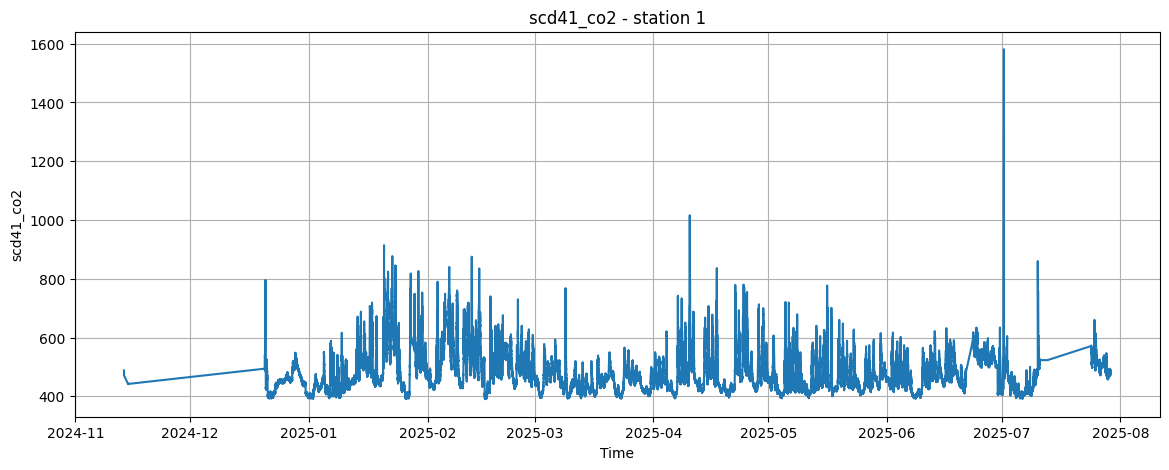

In [3]:
station_id = df[STATION_COL].value_counts().idxmax()
plot_df = df[df[STATION_COL] == station_id].dropna(subset=[TARGET])

plt.figure(figsize=(14, 5))
plt.plot(plot_df["datetime"], plot_df[TARGET])
plt.title(f"scd41_co2 - station {station_id}")
plt.xlabel("Time")
plt.ylabel("scd41_co2")
plt.grid(True)
plt.show()


In [4]:
df = df.sort_values([STATION_COL, "datetime"]).reset_index(drop=True)

for col in FEATURES:
    if col == STATION_COL:
        continue
    df[col] = df.groupby(STATION_COL)[col].transform(lambda x: x.interpolate(limit_direction="both"))
    df[col] = df.groupby(STATION_COL)[col].transform(lambda x: x.ffill().bfill())
    df[col] = df[col].fillna(df[col].median())

print(df[FEATURES].isna().sum())


ens160_aqi               0
ens160_tvoc              0
bme688_gas_resistance    0
bme688_pressure          0
scd41_temperature        0
scd41_humidity           0
scd41_co2                0
hour_sin                 0
hour_cos                 0
dayofweek_sin            0
dayofweek_cos            0
is_weekend               0
station_id               0
dtype: int64


In [5]:
FORECAST_MINUTES = 15
median_step_seconds = df.groupby(STATION_COL)[TIME_COL].diff().dropna().median()
HORIZON_STEPS = round((FORECAST_MINUTES * 60) / median_step_seconds)
FUTURE_TARGET = f"{TARGET}_plus_{FORECAST_MINUTES}min"

df[FUTURE_TARGET] = df.groupby(STATION_COL)[TARGET].shift(-HORIZON_STEPS)
model_df = df[["datetime"] + FEATURES + [FUTURE_TARGET]].dropna().copy()

print("Horizon steps:", HORIZON_STEPS)
print(model_df.shape)
model_df.head()


Horizon steps: 15
(958083, 15)


,datetime,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id,scd41_co2_plus_15min
0,2024-11-13 16:57:56,1,32,12946860.0,100.558,22.951857,36.897277,488.0,-0.866025,-0.500000,0.974928,-0.222521,0,1,525.0
1,2024-11-13 16:58:57,1,30,12946860.0,100.558,22.335011,38.185119,485.0,-0.866025,-0.500000,0.974928,-0.222521,0,1,515.0
2,2024-11-13 16:59:59,1,43,12946860.0,100.558,22.353704,38.400268,477.0,-0.866025,-0.500000,0.974928,-0.222521,0,1,509.0
3,2024-11-13 17:01:03,1,26,12946860.0,100.558,22.417792,38.269042,474.0,-0.965926,-0.258819,0.974928,-0.222521,0,1,504.0
4,2024-11-13 17:02:05,1,31,12946860.0,100.558,22.556649,37.971496,473.0,-0.965926,-0.258819,0.974928,-0.222521,0,1,503.0


In [6]:
train_list, val_list, test_list = [], [], []

for _, group in model_df.groupby(STATION_COL):
    group = group.sort_values("datetime")
    n = len(group)
    train_list.append(group.iloc[:int(n * 0.7)])
    val_list.append(group.iloc[int(n * 0.7):int(n * 0.85)])
    test_list.append(group.iloc[int(n * 0.85):])

train_df = pd.concat(train_list)
val_df = pd.concat(val_list)
test_df = pd.concat(test_list)

feature_mean = train_df[FEATURES].mean()
feature_std = train_df[FEATURES].std().replace(0, 1)
target_mean = train_df[FUTURE_TARGET].mean()
target_std = train_df[FUTURE_TARGET].std()

print(len(train_df), len(val_df), len(test_df))


670657 143712 143714


In [7]:
LOOKBACK = 60
BATCH_SIZE = 512

class WindowDataset(Dataset):
    def __init__(self, data):
        self.groups = []
        self.index = []

        for _, group in data.groupby(STATION_COL):
            group = group.sort_values("datetime")
            x = ((group[FEATURES] - feature_mean) / feature_std).to_numpy(np.float32)
            y = ((group[FUTURE_TARGET] - target_mean) / target_std).to_numpy(np.float32)
            group_id = len(self.groups)
            self.groups.append((x, y))

            for i in range(LOOKBACK - 1, len(group)):
                self.index.append((group_id, i))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        group_id, i = self.index[idx]
        x, y = self.groups[group_id]
        x_window = x[i - LOOKBACK + 1:i + 1].reshape(-1)
        return torch.tensor(x_window), torch.tensor([y[i]])

train_loader = DataLoader(WindowDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(WindowDataset(val_df), batch_size=BATCH_SIZE)
test_loader = DataLoader(WindowDataset(test_df), batch_size=BATCH_SIZE)


In [8]:
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
        )
        self.backcast = nn.Linear(hidden_size, input_size)
        self.forecast = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h = self.net(x)
        return self.backcast(h), self.forecast(h)

class NBeats(nn.Module):
    def __init__(self, input_size, blocks=3):
        super().__init__()
        self.blocks = nn.ModuleList([NBeatsBlock(input_size) for _ in range(blocks)])

    def forward(self, x):
        residual = x
        forecast = torch.zeros((x.size(0), 1), device=x.device)
        for block in self.blocks:
            backcast, block_forecast = block(residual)
            residual = residual - backcast
            forecast = forecast + block_forecast
        return forecast

model = NBeats(LOOKBACK * len(FEATURES)).to(DEVICE)
print(model)


NBeats(
  (blocks): ModuleList(
    (0-2): 3 x NBeatsBlock(
      (net): Sequential(
        (0): Linear(in_features=780, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
      )
      (backcast): Linear(in_features=128, out_features=780, bias=True)
      (forecast): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)


Epoch 1: train=0.0842, val=0.0404
Epoch 2: train=0.0601, val=0.0479
Epoch 3: train=0.0526, val=0.0449
Epoch 4: train=0.0428, val=0.0544
Epoch 5: train=0.0357, val=0.0423
Epoch 6: train=0.0326, val=0.0447
Epoch 7: train=0.0287, val=0.0652
Epoch 8: train=0.0266, val=0.0577
Epoch 9: train=0.0231, val=0.0590
Epoch 10: train=0.0221, val=0.0577


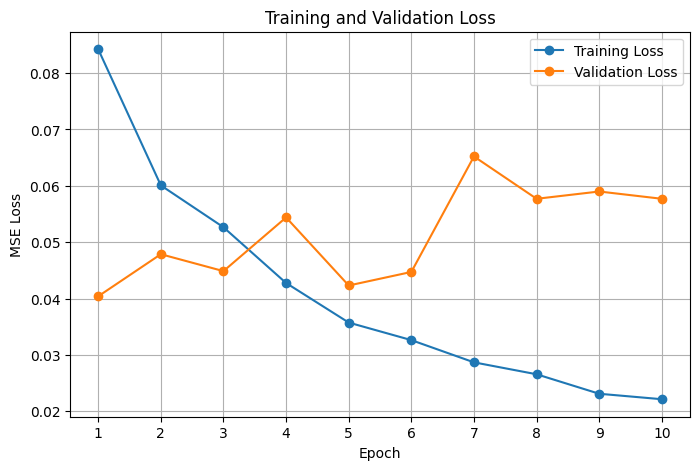

In [9]:
EPOCHS = 10
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

train_losses = []
val_losses = []

def run_epoch(loader, train=False):
    model.train(train)
    total_loss = 0
    count = 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(x)
        count += len(x)

    return total_loss / count

for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch + 1}: train={train_loss:.4f}, val={val_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, marker="o", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.grid(True)
plt.show()


MAE: 19.51
RMSE: 47.49


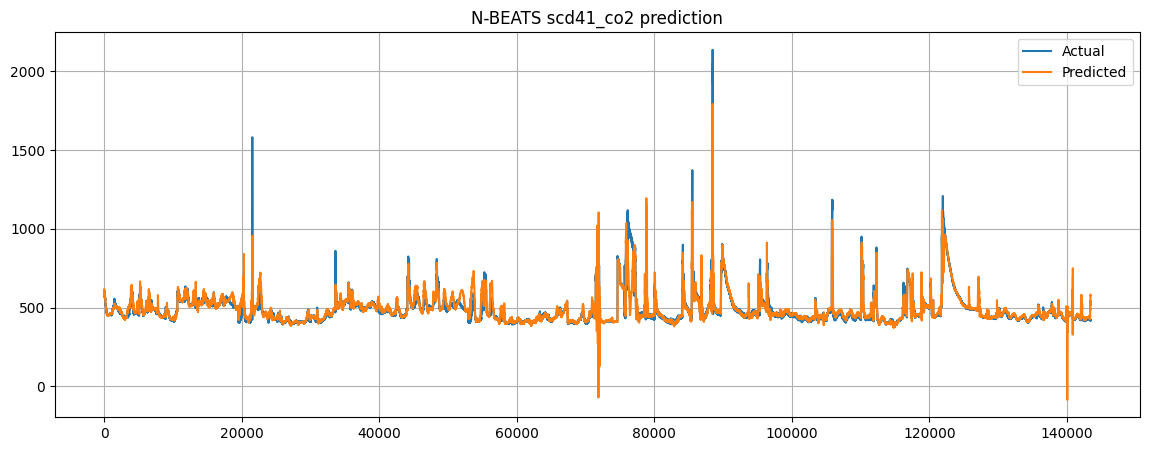

In [10]:
model.eval()
preds, actuals = [], []

with torch.no_grad():
    for x, y in test_loader:
        pred = model(x.to(DEVICE)).cpu().numpy().reshape(-1)
        preds.append(pred)
        actuals.append(y.numpy().reshape(-1))

pred = np.concatenate(preds) * target_std + target_mean
actual = np.concatenate(actuals) * target_std + target_mean

mae = np.mean(np.abs(pred - actual))
rmse = np.sqrt(np.mean((pred - actual) ** 2))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.title("N-BEATS scd41_co2 prediction")
plt.legend()
plt.grid(True)
plt.show()
